# Phase 1: Exploratory Data Analysis & Preprocessing
## Jeddah Real Estate Price Prediction

This notebook performs:
1. Data loading and inspection
2. Data cleaning
3. Feature engineering
4. Descriptive statistics
5. Visualizations
6. Export cleaned dataset for modeling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os
import json
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
%matplotlib inline

## 1. Load and Inspect Raw Data

In [2]:
df = pd.read_csv('Data_Real_Estate2.csv', encoding='utf-8-sig')
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {list(df.columns)}")
df.head(10)

Dataset shape: (6684, 14)

Column names: ['city', 'district', 'district_id', 'furnished', 'ac', 'ketchen', 'age', 'create_time', 'street_width', 'area', 'wc', 'livings', 'beds', 'price']


,city,district,district_id,furnished,ac,ketchen,age,create_time,street_width,area,wc,livings,beds,price
0,جدة,حي الرويس,3488,1,1,1,0,2021-04,13,170,3,1,2,100000
1,جدة,حي العزيزية,3538,1,1,1,3,2021-06,5,20,2,1,2,38000
2,جدة,حي النهضة,3608,1,1,1,3,2021-08,5,25,1,1,2,45000
3,جدة,حي الزمرد,3494,1,1,1,20,2021-08,5,170,3,1,3,65000
4,جدة,حي السلامة,3508,1,1,1,0,2021-11,5,20,1,1,2,42000
5,جدة,حي الرويس,3488,0,1,1,0,2021-11,16,150,2,1,2,52000
6,جدة,حي الرويس,3488,0,1,1,1,2021-11,5,25,2,1,2,54000
7,جدة,حي مشرفة,3648,0,1,1,1,2021-12,5,30,2,1,2,35000
8,جدة,حي الفيحاء,3556,0,1,1,3,2021-12,5,170,3,0,4,75000
9,جدة,حي الحمراء,3470,0,1,1,0,2022-01,28,40,1,1,1,30000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6684 entries, 0 to 6683
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   city          6684 non-null   object
 1   district      6684 non-null   object
 2   district_id   6684 non-null   int64 
 3   furnished     6684 non-null   int64 
 4   ac            6684 non-null   int64 
 5   ketchen       6684 non-null   int64 
 6   age           6684 non-null   int64 
 7   create_time   6684 non-null   object
 8   street_width  6684 non-null   int64 
 9   area          6684 non-null   int64 
 10  wc            6684 non-null   int64 
 11  livings       6684 non-null   int64 
 12  beds          6684 non-null   int64 
 13  price         6684 non-null   int64 
dtypes: int64(11), object(3)
memory usage: 731.2+ KB


In [4]:
df.describe()

,district_id,furnished,ac,ketchen,age,street_width,area,wc,livings,beds,price
count,6684.000000,6684.000000,6684.000000,6684.00000,6684.000000,6684.000000,6684.000000,6684.000000,6684.000000,6684.000000,6684.000000
mean,3536.230401,0.056254,0.211251,0.76556,5.157092,15.288300,169.137044,2.843956,1.073309,3.961700,38322.092759
std,59.775385,0.230428,0.408226,0.42368,6.033289,10.996262,62.079935,0.939614,0.445450,1.197046,22760.907570
min,3422.000000,0.000000,0.000000,0.00000,0.000000,1.000000,16.000000,1.000000,0.000000,1.000000,7000.000000
25%,3492.000000,0.000000,0.000000,1.00000,0.000000,5.000000,120.000000,2.000000,1.000000,3.000000,27000.000000
50%,3528.000000,0.000000,0.000000,1.00000,4.000000,15.000000,168.000000,3.000000,1.000000,4.000000,33000.000000
75%,3586.000000,0.000000,0.000000,1.00000,8.000000,20.000000,200.000000,3.000000,1.000000,5.000000,45000.000000
max,3650.000000,1.000000,1.000000,1.00000,36.000000,100.000000,400.000000,5.000000,5.000000,7.000000,500000.000000


In [5]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values per column:
city            0
district        0
district_id     0
furnished       0
ac              0
ketchen         0
age             0
create_time     0
street_width    0
area            0
wc              0
livings         0
beds            0
price           0
dtype: int64

Duplicate rows: 58


## 2. Data Cleaning

In [6]:
# Drop 'city' column - all rows are Jeddah
df.drop(columns=['city'], inplace=True)

# Fix column name typo
df.rename(columns={'ketchen': 'kitchen'}, inplace=True)

# Remove duplicate rows
duplicates_before = df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Removed {duplicates_before} duplicate rows")
print(f"Shape after cleaning: {df.shape}")

Removed 58 duplicate rows
Shape after cleaning: (6626, 13)


In [7]:
# Validate value ranges
print("Binary columns value counts:")
for col in ['furnished', 'ac', 'kitchen']:
    print(f"  {col}: {sorted(df[col].unique())}")

print(f"\nAge range: {df['age'].min()} - {df['age'].max()}")
print(f"Area range: {df['area'].min()} - {df['area'].max()}")
print(f"Price range: {df['price'].min():,} - {df['price'].max():,}")
print(f"Street width range: {df['street_width'].min()} - {df['street_width'].max()}")
print(f"Beds range: {df['beds'].min()} - {df['beds'].max()}")
print(f"WC range: {df['wc'].min()} - {df['wc'].max()}")
print(f"Livings range: {df['livings'].min()} - {df['livings'].max()}")

Binary columns value counts:
  furnished: [np.int64(0), np.int64(1)]
  ac: [np.int64(0), np.int64(1)]
  kitchen: [np.int64(0), np.int64(1)]

Age range: 0 - 36
Area range: 16 - 400
Price range: 7,000 - 500,000
Street width range: 1 - 100
Beds range: 1 - 7
WC range: 1 - 5
Livings range: 0 - 5


In [8]:
# Outlier detection using IQR method (flag, don't remove)
for col in ['price', 'area', 'street_width']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: Q1={Q1:,.0f}, Q3={Q3:,.0f}, IQR={IQR:,.0f}, "
          f"Bounds=[{lower:,.0f}, {upper:,.0f}], Outliers={outliers}")

print("\nNote: Outliers are flagged but NOT removed - tree-based models are robust to them.")

price: Q1=27,000, Q3=45,000, IQR=18,000, Bounds=[0, 72,000], Outliers=274
area: Q1=120, Q3=200, IQR=80, Bounds=[0, 320], Outliers=106
street_width: Q1=5, Q3=20, IQR=15, Bounds=[-18, 42], Outliers=139

Note: Outliers are flagged but NOT removed - tree-based models are robust to them.


## 3. Feature Engineering

In [9]:
# Extract year and month from create_time
df['year'] = pd.to_datetime(df['create_time']).dt.year
df['month'] = pd.to_datetime(df['create_time']).dt.month
df.drop(columns=['create_time'], inplace=True)

# Create total_rooms feature
df['total_rooms'] = df['beds'] + df['livings'] + df['wc']

# Drop district_id (redundant with district name)
df.drop(columns=['district_id'], inplace=True)

print(f"Columns after feature engineering: {list(df.columns)}")
print(f"Shape: {df.shape}")

Columns after feature engineering: ['district', 'furnished', 'ac', 'kitchen', 'age', 'street_width', 'area', 'wc', 'livings', 'beds', 'price', 'year', 'month', 'total_rooms']
Shape: (6626, 14)


In [10]:
# Group rare districts (fewer than 10 samples) into "Other"
district_counts = df['district'].value_counts()
rare_districts = district_counts[district_counts < 10].index.tolist()
print(f"Total unique districts: {df['district'].nunique()}")
print(f"Rare districts (< 10 samples): {len(rare_districts)}")

df['district'] = df['district'].apply(lambda x: '\u0623\u062e\u0631\u0649' if x in rare_districts else x)
print(f"Districts after grouping: {df['district'].nunique()}")

Total unique districts: 89
Rare districts (< 10 samples): 24
Districts after grouping: 66


## 4. Descriptive Statistics

In [11]:
df.describe()

,furnished,ac,kitchen,age,street_width,area,wc,livings,beds,price,year,month,total_rooms
count,6626.000000,6626.000000,6626.000000,6626.000000,6626.000000,6626.000000,6626.000000,6626.000000,6626.000000,6626.000000,6626.000000,6626.000000,6626.000000
mean,0.056444,0.211591,0.766073,5.164503,15.286447,169.136885,2.843646,1.073800,3.961968,38315.789768,2022.741926,5.408542,7.879414
std,0.230795,0.408467,0.423358,6.045222,11.008418,62.100241,0.941137,0.446523,1.198264,22765.698824,0.440702,3.741558,2.096562
min,0.000000,0.000000,0.000000,0.000000,1.000000,16.000000,1.000000,0.000000,1.000000,7000.000000,2021.000000,1.000000,2.000000
25%,0.000000,0.000000,1.000000,0.000000,5.000000,120.000000,2.000000,1.000000,3.000000,27000.000000,2022.000000,2.000000,6.000000
50%,0.000000,0.000000,1.000000,4.000000,15.000000,168.000000,3.000000,1.000000,4.000000,33000.000000,2023.000000,5.000000,8.000000
75%,0.000000,0.000000,1.000000,8.000000,20.000000,200.000000,3.000000,1.000000,5.000000,45000.000000,2023.000000,8.000000,9.000000
max,1.000000,1.000000,1.000000,36.000000,100.000000,400.000000,5.000000,5.000000,7.000000,500000.000000,2023.000000,12.000000,15.000000


In [12]:
# Value counts for binary features
for col in ['furnished', 'ac', 'kitchen']:
    counts = df[col].value_counts()
    print(f"\n{col}:")
    print(f"  Yes (1): {counts.get(1, 0)} ({counts.get(1, 0)/len(df)*100:.1f}%)")
    print(f"  No  (0): {counts.get(0, 0)} ({counts.get(0, 0)/len(df)*100:.1f}%)")


furnished:
  Yes (1): 374 (5.6%)
  No  (0): 6252 (94.4%)

ac:
  Yes (1): 1402 (21.2%)
  No  (0): 5224 (78.8%)

kitchen:
  Yes (1): 5076 (76.6%)
  No  (0): 1550 (23.4%)


In [13]:
# District frequency and mean price (top 20)
district_stats = df.groupby('district').agg(
    count=('price', 'size'),
    mean_price=('price', 'mean'),
    mean_area=('area', 'mean')
).sort_values('count', ascending=False)

print("Top 20 Districts by Number of Listings:")
district_stats.head(20)

Top 20 Districts by Number of Listings:


,count,mean_price,mean_area
district,,,
حي المروة,509,37777.996071,173.459725
حي السلامة,387,47661.222222,156.736434
حي الحمدانية,323,36136.532508,191.111455
حي الريان,313,30645.367412,163.060703
حي الصفا,308,36007.954545,166.646104
حي الواحة,260,36911.423077,158.738462
حي الروضة,238,50982.773109,166.957983
حي الصوارى,233,43326.180258,187.802575
حي الزهراء,213,49397.178404,156.309859


## 5. Visualizations

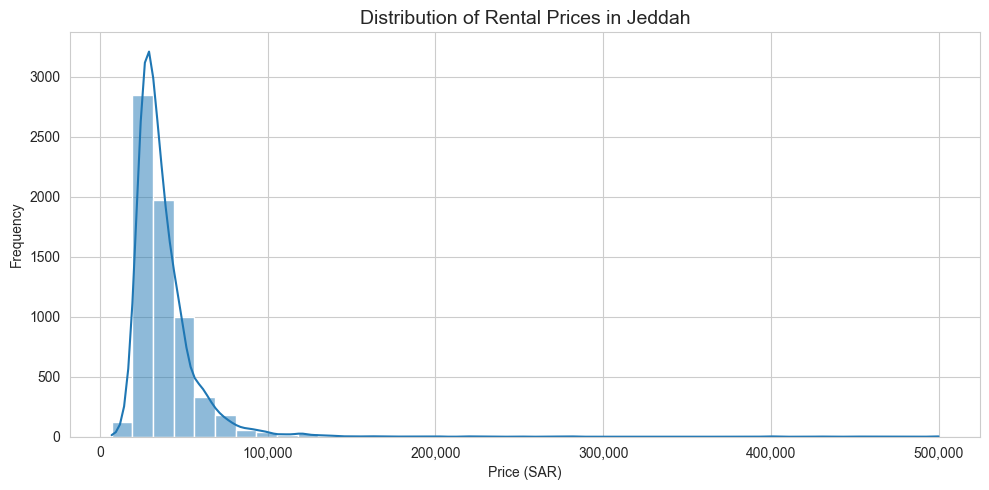

In [14]:
# Chart 1: Price Distribution
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df['price'], bins=40, kde=True, ax=ax)
ax.set_title('Distribution of Rental Prices in Jeddah', fontsize=14)
ax.set_xlabel('Price (SAR)')
ax.set_ylabel('Frequency')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

In [15]:
# Chart 2: Price by District (top 15) - using Plotly for Arabic text
top15 = df['district'].value_counts().head(15).index.tolist()
df_top15 = df[df['district'].isin(top15)]

fig = px.box(df_top15, x='price', y='district', orientation='h',
             title='Price Distribution by District (Top 15)',
             labels={'price': 'Price (SAR)', 'district': 'District'},
             category_orders={'district': top15})
fig.update_layout(height=600, width=900)
fig.show()

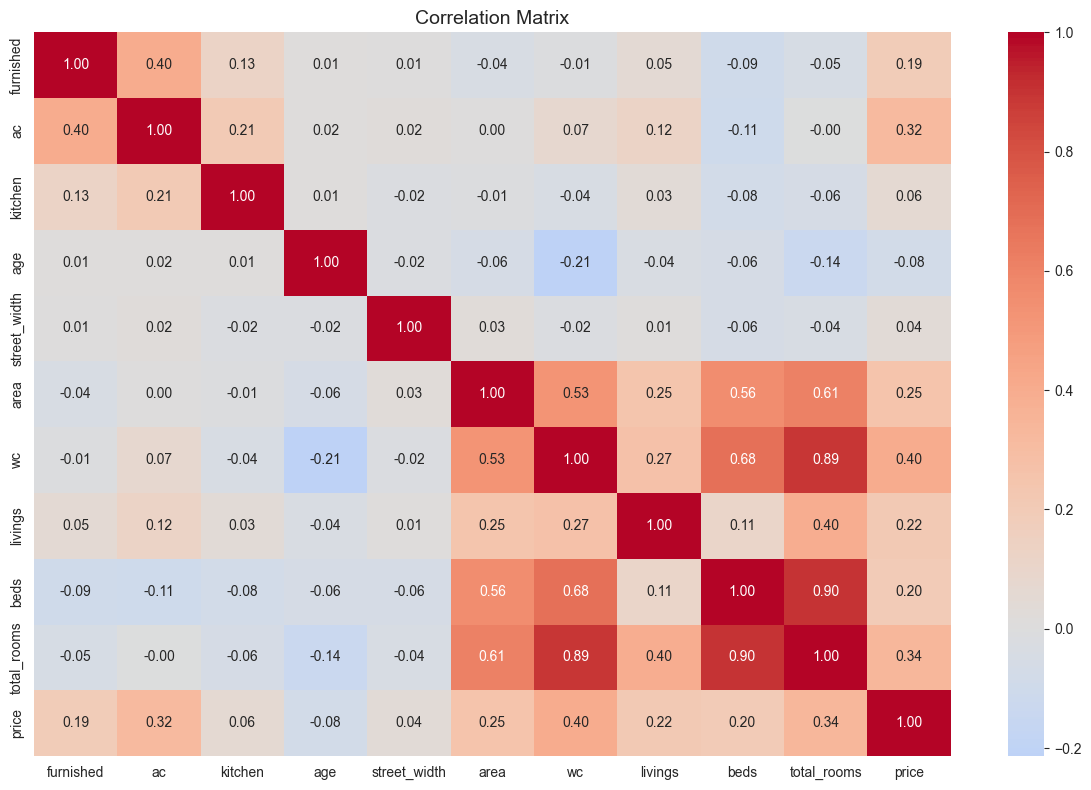

In [16]:
# Chart 3: Correlation Heatmap
numeric_cols = ['furnished', 'ac', 'kitchen', 'age', 'street_width',
                'area', 'wc', 'livings', 'beds', 'total_rooms', 'price']

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm',
            fmt='.2f', center=0, ax=ax)
ax.set_title('Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

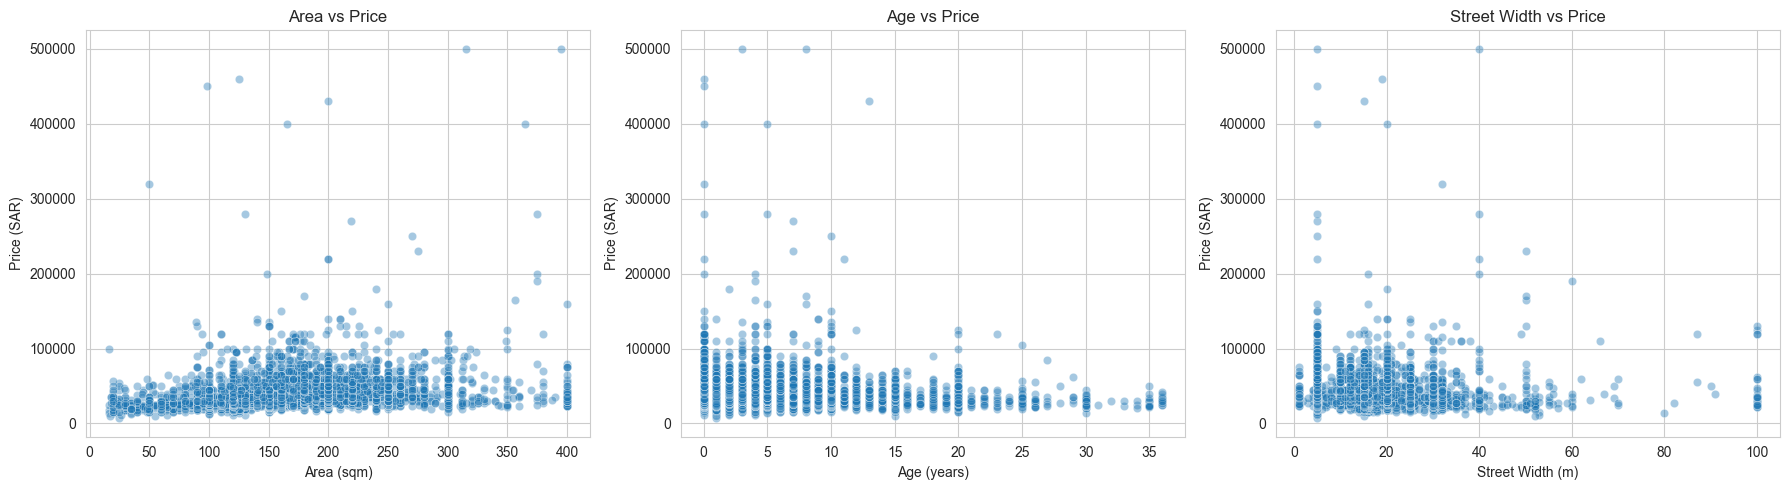

In [17]:
# Chart 4: Scatter Plots - Area, Age, Street Width vs Price
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=df, x='area', y='price', alpha=0.4, ax=axes[0])
axes[0].set_title('Area vs Price')
axes[0].set_xlabel('Area (sqm)')
axes[0].set_ylabel('Price (SAR)')

sns.scatterplot(data=df, x='age', y='price', alpha=0.4, ax=axes[1])
axes[1].set_title('Age vs Price')
axes[1].set_xlabel('Age (years)')
axes[1].set_ylabel('Price (SAR)')

sns.scatterplot(data=df, x='street_width', y='price', alpha=0.4, ax=axes[2])
axes[2].set_title('Street Width vs Price')
axes[2].set_xlabel('Street Width (m)')
axes[2].set_ylabel('Price (SAR)')

plt.tight_layout()
plt.show()

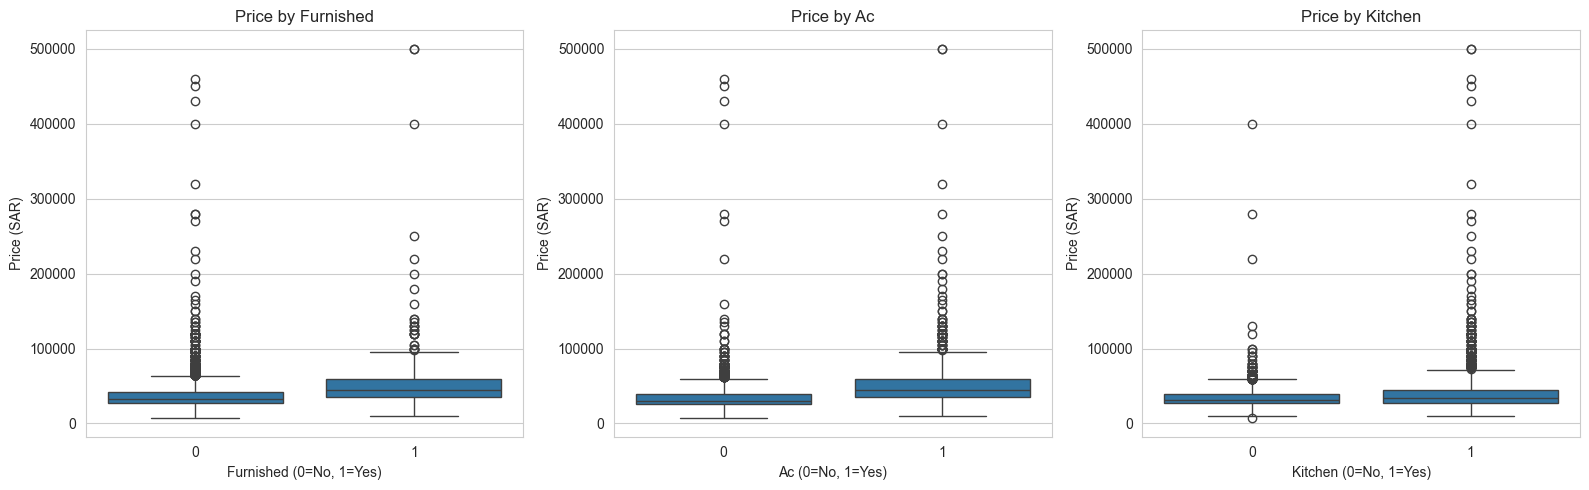

In [18]:
# Chart 5: Box Plots for Binary Features vs Price
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(['furnished', 'ac', 'kitchen']):
    sns.boxplot(data=df, x=col, y='price', ax=axes[i])
    axes[i].set_title(f'Price by {col.capitalize()}')
    axes[i].set_xlabel(f'{col.capitalize()} (0=No, 1=Yes)')
    axes[i].set_ylabel('Price (SAR)')

plt.tight_layout()
plt.show()

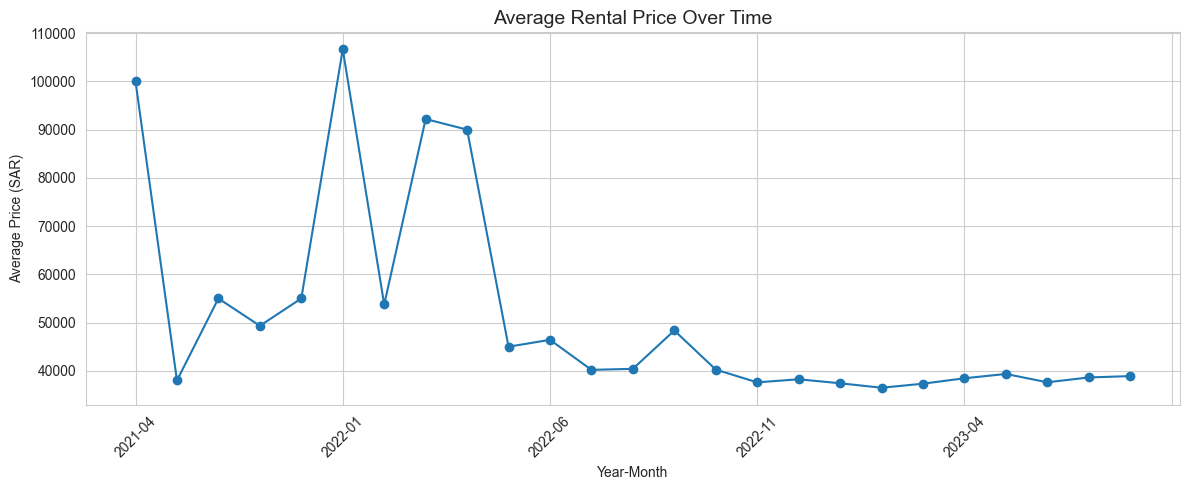

In [19]:
# Chart 6: Price Trend Over Time
df['year_month'] = df['year'].astype(str) + '-' + df['month'].astype(str).str.zfill(2)
price_trend = df.groupby('year_month')['price'].mean().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
price_trend.plot(marker='o', ax=ax)
ax.set_title('Average Rental Price Over Time', fontsize=14)
ax.set_xlabel('Year-Month')
ax.set_ylabel('Average Price (SAR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Drop the helper column
df.drop(columns=['year_month'], inplace=True)

## 6. Save Cleaned Data

In [20]:
# Save cleaned dataset
os.makedirs('data', exist_ok=True)
df.to_csv('data/cleaned_data.csv', index=False, encoding='utf-8-sig')
print(f"Saved cleaned data: {df.shape}")
print(f"Columns: {list(df.columns)}")

# Save district mapping (district name -> mean price) for reference
district_mapping = df.groupby('district')['price'].mean().to_dict()
with open('data/district_mapping.json', 'w', encoding='utf-8') as f:
    json.dump(district_mapping, f, ensure_ascii=False, indent=2)

print(f"\nSaved district mapping with {len(district_mapping)} districts")
print("\nEDA & Preprocessing complete!")

Saved cleaned data: (6626, 14)
Columns: ['district', 'furnished', 'ac', 'kitchen', 'age', 'street_width', 'area', 'wc', 'livings', 'beds', 'price', 'year', 'month', 'total_rooms']

Saved district mapping with 66 districts

EDA & Preprocessing complete!
